Research Question: Which lifestyle factors are most strongly associated with obesity, and how effectively can these behaviors be used to predict whether an individual is obese or not, independent of their physical characteristics?

1. Loading the data 

In [4]:
import os
print(os.getcwd())
print(os.listdir())

/Users/anayanath/rainbow/DS-3021-analytics-1
['xx_Github', '04_ML_Concepts_I_Foundations', '~$nal_project_10.20.21.docx', '#lab dataset2.py', 'Densit Plot kNN Outcomes.pdf', 'Starburst_2 _1_.jpeg', 'A Data Science Degree for the Data Age.pptx', '#ClassData.py', '.DS_Store', 'Kaggle', 'Introduction_Framework_Overview_1.pptx', '#lab 6 analytics class.py', 'requirements.txt', 'analytics_Knn_lab.ipynb', '10_kMeans Clustering', '#lab 5 KNN.py', '02_R_function_basics', '02_function_basics', 'A Degree for the Data Age_Foundations_ML.pptx', '12_Ensemble_RF', 'nba_salaries_22.csv', 'final_project_overview.md', 'scipy.yml', 'US House Votes for Dem Bills.png', 'README.html', 'Advertising Firm Case.pdf', '.devcontainer', 'NBA_Perf_22.csv', 'Ethic Bias Reflection.docx', '#new python file.py', 'revised_linearRegression.ipynb', 'README.md', 'JSON', 'studentdata.csv', '.gitignore', '#lab dataset 1.py', '_config.yml', 'xx_reinforcement-lab', '07_ML_Eval_Metrics', '.github', 'xx_text_mining', '05_ML_Con

In [2]:
import pandas as pd
obesity_data = pd.read_csv("/Users/anayanath/rainbow/DS-3021-analytics-1/data/ObesityDataSet-1.csv", encoding='latin1')


2. Dropping missing values and understanding the data 

In [10]:
#dropped missing values
obesity_data = obesity_data.dropna()


In [13]:
print(obesity_data.head())



   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

In [14]:
print(obesity_data["NObeyesdad"].unique())

['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


3. Exploratory data analysis 

Identifying the most common traits among already obese individuals

In [16]:
#exploratory data analysis 
# Basic summary
obesity_data.describe()



,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [26]:
# Step 1: Filter first on the original (string) labels
obese_df_raw = obesity_data[obesity_data["NObeyesdad"].isin([
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
])]

# Step 2: Now encode if needed
obese_df = obese_df_raw.copy()
le = LabelEncoder()

for col in obese_df.select_dtypes(include=['object']).columns:
    obese_df[col] = le.fit_transform(obese_df[col])

# Step 3: Summary stats
print(obese_df[["Age", "Height", "Weight"]].describe())
print("\nMost common gender (encoded):", obese_df["Gender"].mode()[0])


              Age      Height      Weight
count  972.000000  972.000000  972.000000
mean    25.806181    1.715553  109.082344
std      5.918980    0.088995   17.355499
min     15.000000    1.500000   75.000000
25%     21.681806    1.640744   98.947542
50%     25.138276    1.724095  109.979274
75%     27.933529    1.780193  120.036606
max     52.000000    1.980000  173.000000

Most common gender (encoded): 1


In [25]:
# Decode gender using the original dataset
from sklearn.preprocessing import LabelEncoder

gender_le = LabelEncoder()
gender_le.fit(obesity_data["Gender"])

# Decode most common gender (1)
decoded_gender = gender_le.inverse_transform([1])[0]
print("Most common gender among obese individuals:", decoded_gender)

Most common gender among obese individuals: Male


Histogram of Obesity by gender

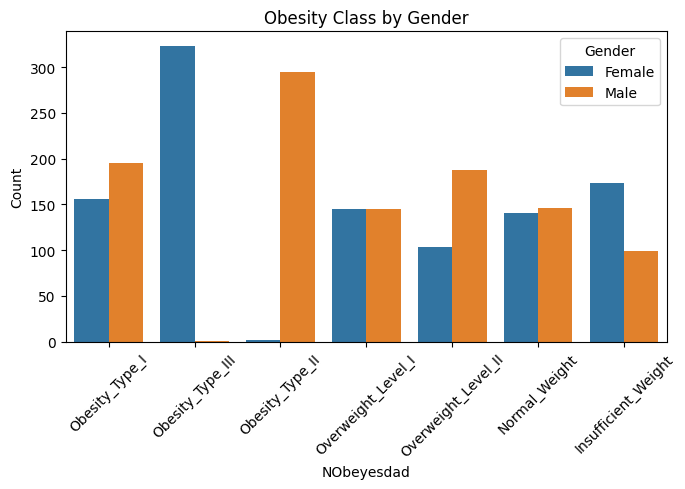

In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(data=obesity_data, x="NObeyesdad", hue="Gender", order=obesity_data["NObeyesdad"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Obesity Class by Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Distribution Plots (e.g. Age, Height, Weight)

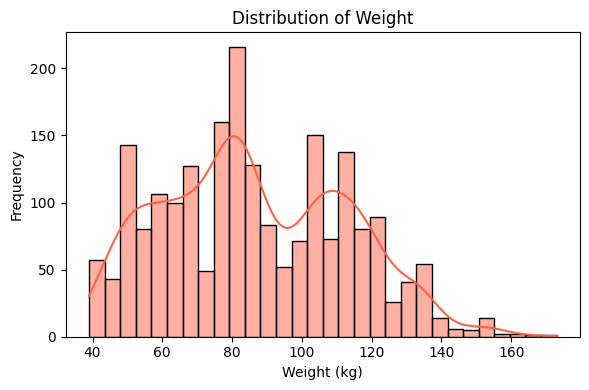

In [19]:
# Histogram of weight
plt.figure(figsize=(6, 4))
sns.histplot(obesity_data["Weight"], bins=30, kde=True, color='tomato')
plt.title("Distribution of Weight")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


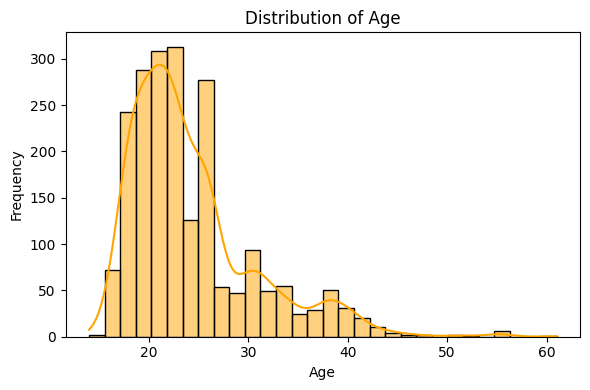

In [29]:
plt.figure(figsize=(6, 4))
sns.histplot(obesity_data["Age"], bins=30, kde=True, color='orange')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


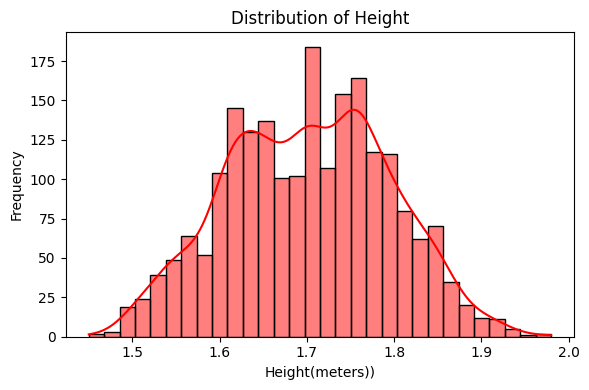

In [32]:
plt.figure(figsize=(6, 4))
sns.histplot(obesity_data["Height"], bins=30, kde=True, color='red')
plt.title("Distribution of Height")
plt.xlabel("Height(meters))")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Among individuals classified as obese in this dataset (i.e., Obesity_Type_I, II, or III), the most common demographic profile is a 25-year-old male, approximately 1.72 meters tall, and weighing around 110 kg. These statistics reflect the average physical characteristics of people who are already obese. 

4. Encoding categorical variables to numerical variables

In [20]:
#encoding variables
from sklearn.preprocessing import LabelEncoder
#Identify all object (i.e., categorical) columns, Use LabelEncoder to convert them into integers
df_encoded = obesity_data.copy()

# Automatically detect object (categorical) columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding to each categorical column
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# View encoded data
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   int64  
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   int64  
 5   FAVC                            2111 non-null   int64  
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   int64  
 9   SMOKE                           2111 non-null   int64  
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   int64  
 12  FAF                             21

5. Calculating the base rate to determine the distribution of obesity classes in the dataset

In [21]:
#In classification, the baserate (also called class prevalence) tells you the proportion of each class (e.g., Normal Weight, Obesity Types) in the dataset. It answers:
## Calculate class distribution (prevalence) of the target
class_distribution = df_encoded['NObeyesdad'].value_counts(normalize=True)

# Multiply by 100 to get percentages
class_distribution_percentage = class_distribution * 100

print("Baserate or Prevalence of each class in NObeyesdad (%):")
print(class_distribution_percentage)

Baserate or Prevalence of each class in NObeyesdad (%):
NObeyesdad
2    16.627191
4    15.348176
3    14.069162
5    13.737565
6    13.737565
1    13.595452
0    12.884889
Name: proportion, dtype: float64


/var/folders/xr/mn6bpzxs6cb3clgq4x9nv3z80000gn/T/ipykernel_43162/4026519680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=obesity_data, x="NObeyesdad", order=obesity_data["NObeyesdad"].value_counts().index, palette="coolwarm")


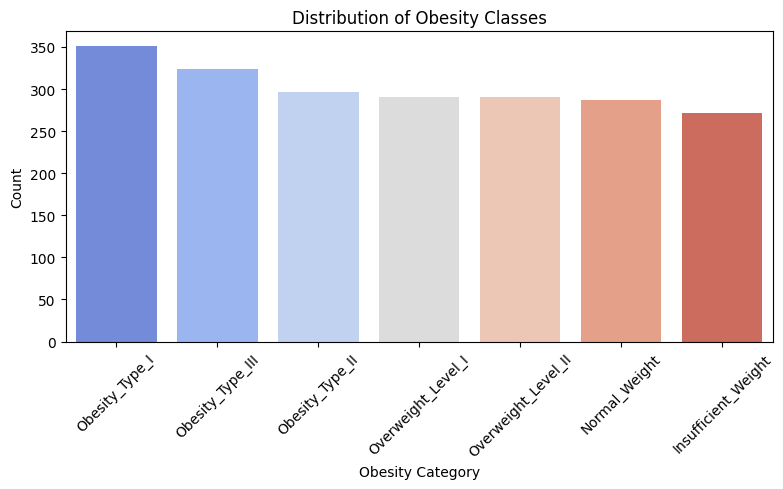

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=obesity_data, x="NObeyesdad", order=obesity_data["NObeyesdad"].value_counts().index, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Distribution of Obesity Classes")
plt.xlabel("Obesity Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The base rate analysis reveals that all obesity-related classes are relatively balanced, ranging from approximately 13% to 17%, indicating no significant class imbalance. This supports the use of balanced accuracy as an appropriate evaluation metric and suggests that resampling techniques will not be necessary. Notably, Obesity Types I, II, and III together account for around 44% of the dataset. This observation justifies why we will proceed with reframing the problem as a binary classification task—distinguishing between obese and non-obese individuals—since it simplifies the target while still capturing meaningful differences in health status. The lower representation of normal and underweight individuals further supports this decision, as the dataset is naturally skewed toward heavier classifications, which aligns well with my goal of identifying behavioral predictors of obesity.

6.  To simplify the classification task while still capturing clinically meaningful distinctions, we created a new binary target variable (Obese_Binary) that labels individuals as obese (1) if they fall into Obesity Types I, II, or III, and non-obese (0) otherwise.




In [34]:
obese_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
# Create new binary target column in original and encoded datasets
obesity_data["Obese_Binary"] = obesity_data["NObeyesdad"].apply(lambda x: 1 if x in obese_classes else 0)
df_encoded["Obese_Binary"] = obesity_data["Obese_Binary"]  # Add to encoded version


7. Exploratory data analysis revealed that physical characteristics such as weight, height, age, and gender played a strong role in distinguishing between obese and non-obese individuals. However, since my goal was to identify the behavioral and lifestyle factors contributing to obesity, I excluded these physical attributes from the final model to focus purely on lifestyle features.

In [35]:
lifestyle_only = ["FAVC", "FCVC", "NCP", "CAEC", "SMOKE", "CH2O", "SCC",
                  "FAF", "TUE", "CALC", "MTRANS"]

X = df_encoded[lifestyle_only]
y = df_encoded["Obese_Binary"]



8. Train-Tune-Test Split (80/10/10) Using Stratified Sampling

In [37]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_tune, y_train, y_tune = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)


9. Optimizing Decision Tree Depth with Grid Search and Repeated Stratified K-Fold

We used GridSearchCV with repeated 10-fold stratified cross-validation to identify the best max_depth for the decision tree. The goal is to improve generalization while accounting for class balance by using balanced_accuracy as the evaluation metric.


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

# Cross-validation setup
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
param_grid = {'max_depth': list(range(1, 21))}
scoring = 'balanced_accuracy'

# Decision tree object
dt_model = DecisionTreeClassifier(random_state=42)

# Grid search
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    scoring=scoring,
    cv=kf,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=5, n_splits=10, random_state=42),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20]},
             scoring='balanced_accuracy')

10. Training the Final Decision Tree Model with Best Depth

After identifying the optimal max_depth through grid search, we used the below code to fit the final decision tree model to the full training data using the best-performing parameters. This trained model will be used for evaluation on the tuning and test sets.

In [39]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)




DecisionTreeClassifier(max_depth=16, random_state=42)

11. Evaluating Model Performance on Train and Tune Sets

This step reports the decision tree’s performance using accuracy and a classification report. By comparing results on the training and tuning sets, we assess how well the model generalizes and whether it may be overfitting. The classification report provides precision, recall, and F1-score to evaluate performance across both classes in the binary obesity prediction task.

In [40]:
# Evaluation
print("Best max_depth:", grid_search.best_params_['max_depth'])
print("Train Accuracy:", accuracy_score(y_train, best_model.predict(X_train)))
print("Tune Accuracy:", accuracy_score(y_tune, best_model.predict(X_tune)))

print("\nClassification Report (Tune Set):")
print(classification_report(y_tune, best_model.predict(X_tune)))


Best max_depth: 16
Train Accuracy: 0.9934834123222749
Tune Accuracy: 0.8767772511848341

Classification Report (Tune Set):
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       114
           1       0.84      0.90      0.87        97

    accuracy                           0.88       211
   macro avg       0.88      0.88      0.88       211
weighted avg       0.88      0.88      0.88       211



12. Using feature importance to identify key lifestyle predictors for Obesity

This step extracts and ranks the most influential lifestyle features used by the decision tree model to predict obesity. Higher importance scores indicate greater contribution to the model's decision-making process.

In [41]:
# Feature importance
feature_importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop Lifestyle Factors Predicting Obesity:")
print(feature_importance.head(5))




Top Lifestyle Factors Predicting Obesity:
NCP     0.164597
FCVC    0.137649
CH2O    0.119460
CAEC    0.115366
FAF     0.115108
dtype: float64


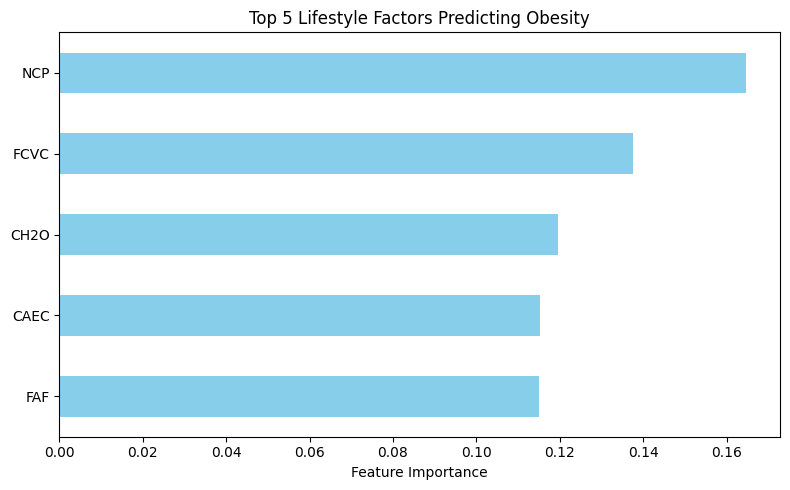

In [42]:

import matplotlib.pyplot as plt

# Get top 5 features
top_features = feature_importance.head(5)

# Plot
plt.figure(figsize=(8, 5))
top_features.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()  # highest importance at the top
plt.title("Top 5 Lifestyle Factors Predicting Obesity")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()


13. Why Early Approaches Failed and How Binary Classification Improved the Model

In the early stages of this project, two approaches were explored that ultimately proved less effective. The first attempt involved identifying the most common demographic profile among obese individuals—based on age, gender, height, and weight. While this provided descriptive insights, it offered no predictive power or understanding of behavioral causes, as it simply summarized who was obese without explaining why. After this demographic profile, we attempted to build a decision tree classifier on individuals already classified as predisposed to obesity to identify lifestyle features most strongly predictive of obesity. This lead to sparse data and risked the model to overfit. Another error was that the 
 decision tree tried to classify between types of obesity (e.g., Obesity Type I, II, III) using lifestyle factors. However, because most obese individuals shared similar behaviors, the model had little variation to learn from, resulting in poor performance and misleading feature importance rankings. Reframing the task as a binary classification—predicting whether an individual is obese or not—proved to be a more effective strategy. This new approach simplified the problem while aligning directly with the research question. By excluding physical traits and focusing solely on behavior, the final model achieved high accuracy and surfaced clear, actionable insights about which habits are most associated with obesity.

14. Model evaluation 

After tuning the model using grid search with repeated stratified cross-validation, the final decision tree achieved 99.3% accuracy on the training set and 87.7% accuracy on the tuning set, with a macro F1-score of 0.88. These results indicate strong generalization without overfitting. The model effectively distinguished obese from non-obese individuals using only lifestyle-related inputs, confirming that certain habits are meaningful predictors of obesity. The top five behavioral predictors identified were: NCP (Number of main meals per day), FCVC (Frequency of vegetable consumption), CH2O (Daily water intake), CAEC (Frequency of eating between meals), FAF (Frequency of physical activity). The use of balanced accuracy as the scoring metric ensured fair evaluation across both classes, accounting for the moderately skewed class distribution.

15. Fairness Assesment

This project focused exclusively on behavioral variables and intentionally excluded demographic and physical features such as gender, weight, height, and age from the final model. As a result, no protected attributes (e.g., gender or race) were used in the classification process, reducing the risk of bias or discriminatory outcomes. The fairness of the model was further supported by the balanced performance across classes, indicating that it did not disproportionately favor one group over another.



16. Conclusion 

The original goal was to identify which lifestyle habits most strongly correlate with obesity. Early attempts to classify between obesity types or create demographic profiles were either non-predictive or not behaviorally informative. Reframing the task as a binary classification problem—obese vs. non-obese—allowed for more actionable insights. By training a decision tree on lifestyle features only, the final model not only achieved strong performance but also surfaced interpretable and policy-relevant predictors of obesity. This supports the idea that obesity can be meaningfully linked to modifiable daily habits rather than fixed physical traits.

17. Recommendations for improvements 

To build on the current findings and enhance the model’s impact, three key areas are recommended for future work. First, implementing ensemble methods such as Random Forest or Gradient Boosting would likely improve predictive accuracy and model stability by reducing overfitting and accounting for feature interactions more effectively than a single decision tree. Second, the model should be validated on external datasets that reflect broader diversity in terms of age, region, and lifestyle patterns to assess generalizability and ensure that the behavioral insights are applicable beyond this sample. Finally, integrating longitudinal or time-series data—such as daily fitness tracking or food logging—could allow for more dynamic modeling, enabling predictions of obesity risk over time rather than static classification. These enhancements would strengthen both the accuracy and real-world usefulness of the model.

------final presentation-------